In [1]:
import numpy as np

In [2]:
# Input image (I)
I = np.array([
    [20, 35, 35, 35, 35, 20],
    [29, 46, 44, 42, 42, 27],
    [16, 25, 21, 19, 19, 12],
    [66, 120, 116, 154, 114, 62],
    [74, 216, 174, 252, 172, 112],
    [70, 210, 170, 250, 170, 110]
])

# 3x3 Filter (K)
K = np.array([
    [1, 1, 1],
    [1, 0, 1],
    [1, 1, 1]
])

# Get Dimensions of input
n, m = I.shape

# Dimensions of kernel
k = K.shape[0]   # (3x3)

# Output Size Calculation
# Output matrix size (valid convolution)
output_size = n - k + 1

# Initialize output matrix with zeros
C = np.zeros((output_size, output_size))

# Perform Convolution
# Slide the kernel over the image
for i in range(output_size):
    for j in range(output_size):

        # Extract 3x3 patch from image
        patch = I[i:i+k, j:j+k]

        # Element-wise multiplication
        multiplied = patch * K

        # Sum of all values
        C[i, j] = np.sum(multiplied)

        # Print step (for understanding)
        print(f"\nPosition C({i},{j})")
        print("Patch:\n", patch)
        print("After applying filter:\n", multiplied)
        print("Sum:", C[i, j])

print("\nFinal Convolution Output:\n", C)


Position C(0,0)
Patch:
 [[20 35 35]
 [29 46 44]
 [16 25 21]]
After applying filter:
 [[20 35 35]
 [29  0 44]
 [16 25 21]]
Sum: 225.0

Position C(0,1)
Patch:
 [[35 35 35]
 [46 44 42]
 [25 21 19]]
After applying filter:
 [[35 35 35]
 [46  0 42]
 [25 21 19]]
Sum: 258.0

Position C(0,2)
Patch:
 [[35 35 35]
 [44 42 42]
 [21 19 19]]
After applying filter:
 [[35 35 35]
 [44  0 42]
 [21 19 19]]
Sum: 250.0

Position C(0,3)
Patch:
 [[35 35 20]
 [42 42 27]
 [19 19 12]]
After applying filter:
 [[35 35 20]
 [42  0 27]
 [19 19 12]]
Sum: 209.0

Position C(1,0)
Patch:
 [[ 29  46  44]
 [ 16  25  21]
 [ 66 120 116]]
After applying filter:
 [[ 29  46  44]
 [ 16   0  21]
 [ 66 120 116]]
Sum: 458.0

Position C(1,1)
Patch:
 [[ 46  44  42]
 [ 25  21  19]
 [120 116 154]]
After applying filter:
 [[ 46  44  42]
 [ 25   0  19]
 [120 116 154]]
Sum: 566.0

Position C(1,2)
Patch:
 [[ 44  42  42]
 [ 21  19  19]
 [116 154 114]]
After applying filter:
 [[ 44  42  42]
 [ 21   0  19]
 [116 154 114]]
Sum: 552.0

Positio

Observation:

This program performs a manual 2D convolution operation on a 6×6 input image matrix using a 3×3 filter kernel to demonstrate the basic process of convolution in image processing. The input matrix I represents grayscale pixel intensity values, while the kernel K is a custom filter that considers all surrounding neighboring pixels except the center pixel, making it useful for analyzing local neighborhood information.

The code first calculates the dimensions of both the image and kernel, then determines the size of the output matrix based on valid convolution (without padding), resulting in a smaller output. It slides the 3×3 filter across the image one step at a time, extracts each corresponding 3×3 patch, performs element-wise multiplication between the patch and filter, and computes the sum of the multiplied values to produce each value of the output matrix C. Additionally, the program prints every intermediate step, including the current patch, filtered result, and sum, allowing users to understand how convolution is calculated at each position. Finally, it displays the complete convolution output matrix, making this code a clear educational example of how convolution works mathematically in digital image processing and convolutional neural networks.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving panda.jpg to panda.jpg


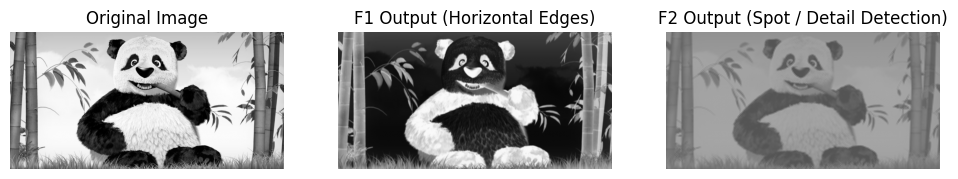

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Function: Convolution without padding (VALID)
def conv2d_nopadding(image, kernel):
    # Get the dimensions of the image and kernel
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # Calculate output dimensions (valid convolution)
    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1

    # Initialize output matrix with zeros
    output = np.zeros((output_height, output_width))

    # Perform convolution
    for i in range(output_height):
        for j in range(output_width):
            # Extract region of same size as kernel
            region = image[i:i + kernel_height, j:j + kernel_width]

            # Element-wise multiplication and sum
            output[i, j] = np.sum(region * kernel)

    return output

# Load Lenna Image (Grayscale)
image = cv2.imread('panda.jpg', cv2.IMREAD_GRAYSCALE)

# Check if image loaded
if image is None:
    print("Error: Image not found!")
    exit()

# Define Kernels given in question

# Kernel 1 (F1) → Horizontal Edge Detector
F1 = np.array([
    [-10, -10, -10],
    [  5,   5,   5],
    [-10, -10, -10]
])

# Kernel 2 (F2) → Center-Surround / Spot Detector
F2 = np.array([
    [ 2,  2,  2],
    [ 2, -12, 2],
    [ 2,  2,  2]
])


# --------------------------------------------------
# Apply Convolution
# --------------------------------------------------
output_F1 = conv2d_nopadding(image, F1)
output_F2 = conv2d_nopadding(image, F2)


# --------------------------------------------------
# Display Results
# --------------------------------------------------
plt.figure(figsize=(12, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

# Result using Kernel F1
plt.subplot(1, 3, 2)
plt.title("F1 Output (Horizontal Edges)")
plt.imshow(output_F1, cmap='gray')
plt.axis('off')

# Result using Kernel F2
plt.subplot(1, 3, 3)
plt.title("F2 Output (Spot / Detail Detection)")
plt.imshow(output_F2, cmap='gray')
plt.axis('off')

plt.show()

Observation:

This Python program loads the Lenna image in grayscale, applies two custom 3×3 convolution filters, and displays the filtered outputs alongside the original image using Matplotlib. A manual convolution function named conv2d_nopadding() is implemented to perform 2D convolution without padding, meaning the output image becomes slightly smaller because border pixels are excluded. The first filter (F1) is designed as a horizontal edge detector, emphasizing horizontal intensity changes in the image to highlight horizontal edges and boundaries. The second filter (F2) acts as a center-surround or spot detector, which enhances isolated bright or dark spots and local texture variations by comparing the center pixel against its surrounding neighbors. After checking whether the image is loaded correctly, the code convolves the image separately with both filters and visualizes the original image, horizontal edge-detected image, and spot-detected image in a side-by-side subplot layout. Overall, this program demonstrates the basic concept of image filtering and feature extraction using convolution kernels in digital image processing.